## Graphs for Netflix Streaming data

The Netflix streaming dataset on Kaggle provides structured information about movies and TV shows available on the platform, including key metadata such as title, type, release year, and content ratings. It typically also includes descriptive attributes like genre, country of production, and a short synopsis, enabling both qualitative and quantitative analysis of Netflix’s catalog. Some versions further enrich the data with external indicators such as IMDb scores, vote counts, and popularity metrics from third-party services. It offers a realistic, moderately large dataset for practicing data cleaning, visualization, and modeling in the context of modern streaming media. [vault.nimc.gov](https://vault.nimc.gov.ng/blog/netflix-dataset-analysis-a-kaggle-exploration-1764797697)

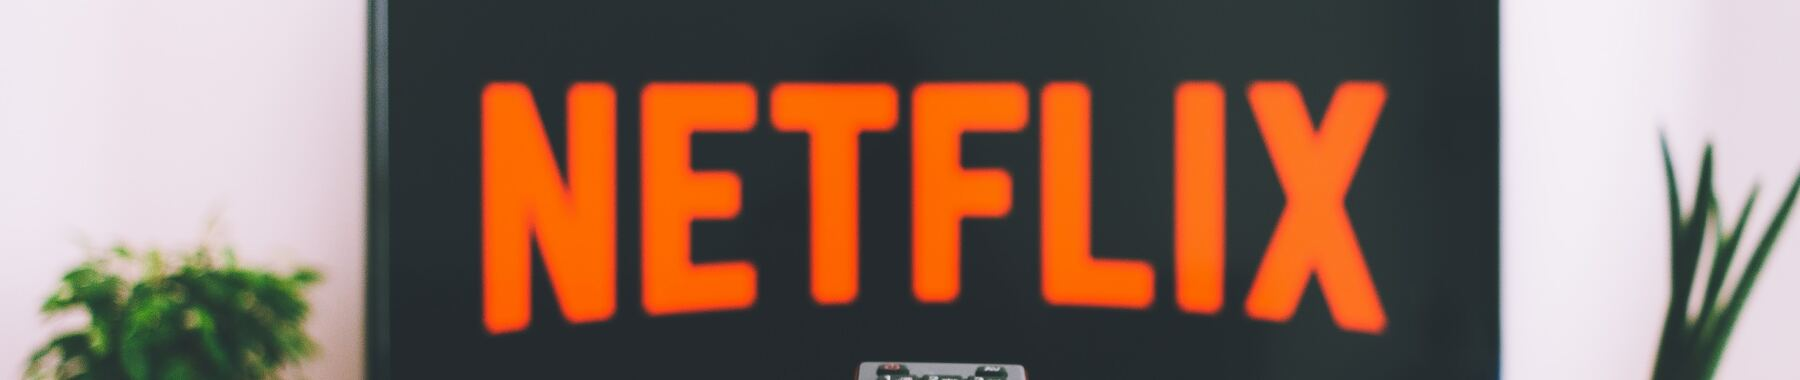

In this notebook, I'm going to construct 3 graphs from the Netflix Steaming dataset as follows:
1. I construct a bipartite graph `B`, where `B` comprises two node sets, namely the `actor name` node set and the `movie title` node set. I call this graph the _**movie-actor graph**_.
1. I apply projection onto the `actor name` node set to create the graph `C` from the bipartite graph `B`. I call `C` the _**co-actor graph**_.
1. I apply projection onto the `movie title` node set to create the graph `S` from the bipartite graph `B`. I call `S` the _**shared-actor graph**_.

![](img/three%20graphs.png)

---

### Setup

#### Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import networkx as nx
import json

---

### Prepare dataset for graph construction

#### Load cleaned dataset.

In [ ]:
# Load dataset
df_clean = pd.read_pickle('./datasets/Netflix Streaming Data/Netflix Streaming Data-Cleaned.pkl')
print(df_clean.info())
df_clean.head()

#### Overview

1. Remove entries with empty `cast` entries
1. Remove unnecessary rows: TV shows
2. Check whether `show_ids` are unique.
3. Check whether `titles` are unique.
4. Calculate the set of nodes `actor_names`: Tokenize the `cast` field.
5. Check whether there is an intersection between `movie_titles` and `actor_names`.
6. Some statistics: average number of `actors` per `movie` etc.

#### Remove empty `cast` entries

Consider only entries with non-null "cast" entries

In [ ]:
df_cast = df_clean.dropna(subset=['cast'])
df_cast = df_cast.reset_index(drop=True)
df_cast.info()

#### Remove entries for TV shows

Consider only entries of type = "Movie".

In [ ]:
df_movie = df_cast[df_cast['type'] == 'Movie']
df_movie = df_movie.reset_index(drop=True)
df_movie.info()

#### We need unique identifiers for movies

Start with analysing `title`, `show-id` and `actor` entries.

In [ ]:
titles = set(df_movie['title'].unique())
actors = set()
show_ids = set(df_movie['show_id'].unique())
for idx, row in df_movie.iterrows():
    actors.update([actor.strip() for actor in row['cast'].split(',')])
print(f"Total unique titles: {len(titles)}")
print(f"Total unique actors: {len(actors)}")
print(f"Total unique show IDs: {len(show_ids)}")

Aside: Make list of actors for a sample title.

In [ ]:
actors_Sankofa = df_movie[df_movie['title'] == 'Sankofa']['cast'].values[0].split(',')
actors_Sankofa = [actor.strip() for actor in actors_Sankofa]
actors_Sankofa

For constructing the bipartite graph, we need unique identifiers for movies. Can we use the `title` entry for this purpose?
We check, if there is an overlap between `titles` and `actors` sets.

In [ ]:
intersect = titles.intersection(actors)
print(f"Movie titles that are also actor names: {intersect}")

As the intersection between the `movie_titles` set and the `actor_names` set is not null, we cannot use the `title` entry for the construction of the bipartite graph; we have to use the `show_ids` set instead to construct the bipartite graph. 

---

### Initial statistics

Before constructing the bipartite graph, we create a histogram for the number of actors peer movie.

In [ ]:
# AI-generated content: This code computes the number of actors per movie, provides summary statistics, 
# and visualizes the distribution of actor counts per movie using a histogram. 
# It also prints the distribution of actor counts for the first 20 counts. 
# The prompt was: "compute a histogram for the number of actors per movie."

# Compute the number of actors per movie (split cast by comma and strip whitespace)

def count_actors(cast_str: str) -> int:
    cast = [actor.strip() for actor in cast_str.split(',')]
    return len(cast)

actors_per_movie = df_movie['cast'].fillna('').apply(count_actors)

# Summary statistics
print(actors_per_movie.describe())

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(actors_per_movie, bins=range(1, actors_per_movie.max() + 2), edgecolor='black')

# The hist method bins the data in x and counts the number of values in each bin, then draws the distribution either as a BarContainer or Polygon.
# Note: bins start at 1 since movies with 0 actors are not meaningful in this context.

plt.xlabel('Number of actors per movie')
plt.ylabel('Number of movies')
plt.title('Histogram of actor counts per movie')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# Print distribution of actor counts
actor_count_dist = actors_per_movie.value_counts().sort_index()
print(actor_count_dist.head(20))

Which movie has 44 actors?

In [ ]:
mv44 = df_movie[actors_per_movie == 44]
print(mv44[['title']])
for i, act in enumerate(mv44['cast'].iloc[0].split(','), 1):
    print(f"{i}: {act.strip()}")

Create histogram for movies per year.

In [ ]:
# Histogram of the number of movies per movie releaseyear.
# Choose the correct year column (some Netflix datasets use "release_year").
if 'release_year' in df_movie.columns:
    year_col = 'release_year'
elif 'year' in df_movie.columns:
    year_col = 'year'
else:
    raise KeyError('No year column found in df_movie')

# Count movies per year and sort by year
movies_per_year = df_movie[year_col].value_counts().sort_index()

plt.figure(figsize=(12, 6))
# Use bar plot to show counts per year
movies_per_year.plot(kind='bar', color='tab:blue', edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Number of movies')
plt.title('Number of Movies per ReleaseYear')
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()

# Print a quick summary of the counts
print(movies_per_year.head(20))

Histogram of movies added to Netflix per year.

In [ ]:
# Ensure date_added is a datetime type (some datasets store it as a string)
df_movie['date_added'] = pd.to_datetime(df_movie['date_added'], errors='coerce')

# Extract the year when each title was added to Netflix
df_movie['added_year'] = df_movie['date_added'].dt.year

# Count movies by the year they were added to Netflix
movies_added_per_year = (
    df_movie['added_year']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
movies_added_per_year.plot(kind='bar', color='tab:green', edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.title('Netflix Titles Added per Year')
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()

# Quick summary
print(movies_added_per_year.head(20))
print('Check: Total titles counted:', movies_added_per_year.sum())


Now, let's construct a histogram for the release years of movies added in 2021 to Netflix.

In [ ]:
# Histogram of release dates for movies added in 2021
added_2021 = df_movie[df_movie['added_year'] == 2021].copy()
if added_2021.empty:
    print('No titles found with added_year == 2021')
else:
    # Determine the correct release year column name
    if 'release_year' in added_2021.columns:
        release_col = 'release_year'
    elif 'year' in added_2021.columns:
        release_col = 'year'
    else:
        raise KeyError('No release year column found in df_movie')

    release_year_counts = (
        added_2021[release_col]
        .dropna()
        .astype(int)
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(12, 6))
    release_year_counts.plot(kind='bar', color='tab:purple', edgecolor='black')
    plt.xlabel('Release Year')
    plt.ylabel('Number of Movies (added in 2021)')
    plt.title('Release Year Distribution for Movies Added in 2021')
    plt.grid(axis='y', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print(release_year_counts)

---

### Bipartite graph `B`

#### Create and check bipartite graph

In [ ]:
B = nx.Graph()

for idx, row in df_movie.iterrows():
    tit = row['title']
    acts = [act.strip() for act in row['cast'].split(',')]
    for act in acts:
        B.add_edge(tit, act)
for node in list(B.nodes(data=True))[200:250]:
    print(node)

#### Check if graph is bipartite

Key concept: A graph is bipartite if and only if it can be colored with 2 colors such that no adjacent nodes have the same color (equivalently, it contains no odd-length cycles).

For the movie-actor graph, B should definitely be bipartite since it connects titles to actors with no actor-to-actor or title-to-title edges.

To check if a graph is bipartite check for odd cycles.

(Bipartite graphs do not contain odd cycles because all edges in such graphs strictly connect distinct, disjoint vertex sets `A` and `B`. Any path starting in `A`, passing through an odd number of edges (e.g., `A` → `B` → `A` → `B`)), must end in a different partition `B`, making it impossible to return to the starting vertex in an odd number of steps.) Example: In the graph below, count the number of edges you pass, if you leave node `1` and return to that node.

![](img/cycles.jpg)

In [ ]:
# If the graph has odd cycles, this will be slow or fail
cycle_basis = nx.cycle_basis(B)
has_odd_cycle = any(len(cycle) % 2 == 1 for cycle in cycle_basis)
if has_odd_cycle:
    print("Graph is NOT bipartite (contains odd cycles).")
else:
    print("Graph is bipartite.")

As we know already, there is an overlap in the "title" and "actor" sets, i.e. 
a movie title is also an actor name. 

Instead of "title", we have to use "show_id".

In order not to loose the movie title, we add an attribute `movie_title` to the movie nodes, that tells us the movie title.

In [ ]:
B = nx.Graph()

for idx, row in df_movie.iterrows():
    # Use show_id as the unique node identifier, but keep the movie title as an attribute.
    show_id = row['show_id']
    B.add_node(show_id, movie_title=row['title'])

    acts = [actor.strip() for actor in row['cast'].split(',')]
    for act in acts:
        B.add_edge(show_id, act)

for node in list(B.nodes(data=True))[200:250]:
    print(node)

Re-check, if graph is bipartite.

In [ ]:
# If the graph has odd cycles, this will be slow or fail
cycle_basis = nx.cycle_basis(B)
has_odd_cycle = any(len(cycle) % 2 == 1 for cycle in cycle_basis)
if has_odd_cycle:
    print("Graph is NOT bipartite (contains odd cycles).")
else:
    print("Graph is bipartite.")

#### Analyze bipartite graph

Next step: Find the titles of those movies that do not share actors with any other movie.

If a movie appears in a connected component with only 1 title node, all of its actors are unique to that movie and don't appear in any other movie in the dataset.

In [ ]:
components_B = list(nx.connected_components(B))

no_of_single_title_components = 0
no_of_actors_in_single_title_components = 0

for component in components_B:
    titles_in_comp = [node for node in component if node in titles]
    
    if len(titles_in_comp) == 1:
        no_of_single_title_components += 1
        movie = titles_in_comp[0]
        # Get the cast from the original dataframe
        cast = df_movie[df_movie['title'] == movie]['cast'].values[0]
        no_of_actors_in_single_title_components += len(cast.split(',')) 
        print(f"{movie}")
        print(f"  Cast: {cast}\n")

print(f"Total number of single-title components: {no_of_single_title_components}")
print(f"Total number of actors in single-title components: {no_of_actors_in_single_title_components}\n")

print("Top 20 largest components (by number of nodes):")
components_B.sort(key=len, reverse=True)
for i, component in enumerate(components_B[:20], 1):
    print(f"Component {i}: {len(component)} nodes")

Create a histrogram for the size of the connected components in `B`.

In [ ]:
# Compute connected component sizes for B
components_B = list(nx.connected_components(B))
component_sizes = [len(c) for c in components_B]

plt.figure(figsize=(10, 5))
plt.hist(component_sizes, bins=range(1, 40, 1), edgecolor='black')
plt.xlabel('Connected component size (number of nodes)')
plt.ylabel('Number of components')
plt.title('Histogram of connected component sizes in B')
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()

# Print summary stats
from collections import Counter
size_counts = Counter(component_sizes)
print('Number of connected components:', len(components_B))
sizes_sorted = dict(sorted(size_counts.items()))
print('Connected component sizes:')
for size, count in sizes_sorted.items():
    print(f'  Size {size}: {count} components')

    

---

### Co-actor graph `C`

#### Create co-actor graph

In [ ]:
from networkx.algorithms import bipartite
print(len(actors))
# Project onto actors
C = bipartite.weighted_projected_graph(B, actors)
print(list(C.edges(data=True))[:10])  # Display first 10 edges with weights
print(len(C.nodes()), 'nodes in projected graph C')

#### Serialize to node-link format

In [ ]:
fn = f'graphs/co-actor_graph.json'
with open(fn, 'w', encoding='utf-8') as f:
    json.dump(nx.node_link_data(C), f, indent=2, ensure_ascii=False)

#### Analyze co-actor graph

Count connected components in graph `C`.

In [ ]:
components_C = list(nx.connected_components(C))
print(f"Number of connected components: {len(components_C)}\n")

sum_nodes = sum(len(component) for component in components_C)
print(f"Total number of actor nodes across all connected components: {sum_nodes}")

Find connected components with 5 or less actor nodes.

In [ ]:
small_components_C = [c for c in components_C if len(c) <= 10]
print(f"Found {len(small_components_C)} components with 10 or less nodes\n")

#for i, c in enumerate(small_components_C, 1):
#    print(f"Connected component {i}: {len(c)} nodes")
#    if len(c) <= 10:
#        print(f"  Nodes: {c}")

Compute distribution of connected component sizes of co-actor graph

In [ ]:
# Get the size of each component
component_sizes = [len(comp) for comp in components_C]

# Build a distribution (size -> count of components with that size)
size_dist = Counter(component_sizes)

# Optional: sort by component size
size_dist_sorted = dict(sorted(size_dist.items()))

print("Component size distribution (size -> count):")
for size, count in size_dist_sorted.items():
    print(f"  {size:3d} nodes : {count} components")

# Optionally: inspect the largest components
largest = sorted(component_sizes, reverse=True)[:10]
print("\nLargest component sizes:", largest)

Show distribution

In [ ]:
# Filter for component sizes < 35
filtered_sizes = [s for s in component_sizes if s < 35]

# Ensure we show all sizes from 1 to 34 (even if zero components)
sizes = list(range(1, 35))
counts = [filtered_sizes.count(s) for s in sizes]

plt.figure(figsize=(10, 5))
plt.bar(sizes, counts, width=0.8, edgecolor="black")
plt.xlabel("Connected Component size (number of actors)")
plt.ylabel("Number of Connected Components")
plt.title("Distribution of Connected Component sizes < 35 for graph C")
plt.xticks(sizes, rotation=45)
plt.grid(axis="y", alpha=0.6)
plt.tight_layout()
plt.show()

Binned distribution; optional coloring.

In [ ]:
# Compute connected components and their sizes
component_sizes = [len(comp) for comp in components_C]

# Filter for component sizes < 35
filtered_sizes = [s for s in component_sizes if s < 35]

# Define bins of width 5: [0-4], [5-9], ..., [30-34]
bin_edges = list(range(0, 36, 5))  # 0,5,10,...,35
bin_labels = [f"{bin_edges[i]}-{bin_edges[i+1]-1}" for i in range(len(bin_edges)-1)]

# Use numpy histogram to bin
import numpy as np
counts, _ = np.histogram(filtered_sizes, bins=bin_edges)

palette_8 = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
]

# Use one color per bin (7 bins)
colors = [palette_8[i % 7] for i in range(len(counts))]

plt.figure(figsize=(10, 5))
plt.bar(bin_labels, counts, width=0.8,  edgecolor="black")  # insert color=colors to color bars
plt.xlabel("Component size range (actors)")
plt.ylabel("Number of components")
plt.title("Distribution of Connected Component Sizes (< 35) in Graph C (bin size=5)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.6)
plt.tight_layout()
plt.show()

#### Visualize co-actor graph

Create initial visualization and save to file.

In [ ]:
# Draw co-actor graph with a simple style (no node labels, no node-color encoding)
plt.figure(figsize=(20, 20))
pos = nx.spring_layout(C, k=2, iterations=10, seed=42)

nx.draw(
    C,
    pos,
    with_labels=False,
    node_color='lightcoral',
    node_size=50,
    edge_color='lightgray',
    width=0.5,
)

plt.title('Co-actor graph (simple view, no node labels)')
plt.axis('off')

plt.savefig('graphs/co-actor_graph_simple.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig('graphs/co-actor_graph_simple.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

High degree ≠ guaranteed center
A node with many edges still gets pushed around by the total force balance from all connected edges and all other nodes’ repulsion. If it has many edges to nodes that are themselves clustered or pulling in one direction, the equilibrium position can end up “off to the side.”

#### Analyze co-actor graph further

Several degree distributions

In [ ]:
degrees = dict(C.degree())
degree_df = pd.DataFrame(list(degrees.items()), columns=['actor', 'degree'])
degree_df = degree_df.sort_values(by='degree', ascending=False)

# Top 100 actors by degree (number of co-actor connections)
top_100 = degree_df.head(100)
print (top_100)
plt.figure(figsize=(15, 30))
plt.barh(top_100['actor'], top_100['degree'], color='orange')
plt.xlabel('Degree')
plt.ylabel('Actor')
plt.title('Top 100 Actors by Co-actor Connections')
plt.gca().invert_yaxis()
plt.savefig('graphs/co-actor_degree_dist_top100.svg', format='svg', bbox_inches='tight')
plt.show()

![](img/Anupam%20Kher.webp)

Anupam Kher

![](img/Shah_Rukh_Khan.jpg)

Shah Rukh Khan

How many actors have a degree = 0?

In [ ]:
# Actors with degree = 0
bottom = degree_df[degree_df['degree'] == 0]
print (bottom)

In [ ]:
print(f"Ronnie Coleman's degree in graph C: {C.degree('Ronnie Coleman')}")

Who wants to have Ronnie Coleman as co-actor?

![](img/Ronnie_Coleman.png)

---

### Shared-actor graph `S`

#### Create shared-actor graph

In [ ]:
from networkx.algorithms import bipartite
print(len(show_ids))
# Project onto show IDs
S = bipartite.weighted_projected_graph(B, show_ids)
print(list(S.edges(data=True))[:10])  # Display first 10 edges with weights
print(len(S.nodes()), 'nodes in projected graph S')

#### Visualize shared-actor graph

In [ ]:
plt.figure(figsize=(200, 200))
pos = nx.spring_layout(S, k=2, iterations=10)
nx.draw(S, pos, with_labels=True, node_color='lightcoral', node_size=300, font_size=6, width=0.5)
plt.savefig('graphs/shared-actor_graph.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig('graphs/shared-actor_graph.png', format='png', dpi=300, bbox_inches='tight')
plt.show()